# Case 7: Klastering Berdasarkan Sektor & Profil Usaha

Segmentasi yang fokus murni pada tipe *business model* dari UMKM (Sektor, Bidang, dan Kegiatan Usahanya).

**Fokus Fitur yang Digunakan:**
- Sektor Numeric
- Bidang Usaha Numeric
- Omset Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [8]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Sektor Numeric', 'Bidang Usaha Numeric', 'Omset Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Sektor Numeric,Bidang Usaha Numeric,Omset Numeric
0,NASYWA SNACK,20,3,5.0
1,WARUNG ABINAYA,20,4,5.0
2,TUNGKU MA ENDANG,20,3,5.0
3,WARUNG BU WIWIK,12,1,5.0
4,WARUNG PNUNG,20,4,5.0


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


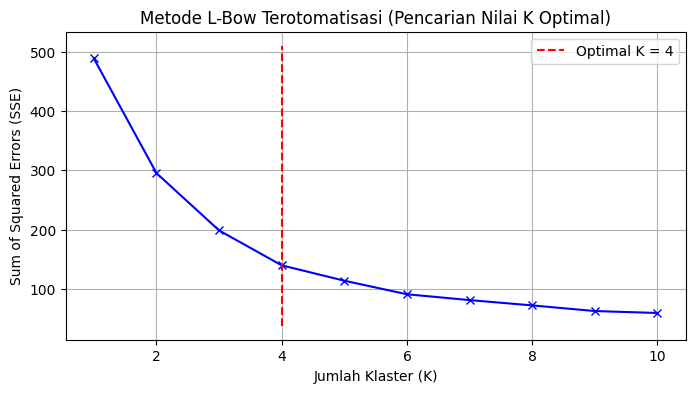

Rekomendasi K-Optimal adalah: 4


In [9]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi KMeans

In [10]:
print(f"Mengeksekusi K-Means Konvensional untuk K={optimal_k}...")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = kmeans.fit_predict(X_scaled)
final_centroids_scaled = kmeans.cluster_centers_


df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi K-Means Konvensional untuk K=4...


,Nama Usaha,Sektor Numeric,Bidang Usaha Numeric,Omset Numeric,Cluster
0,NASYWA SNACK,20,3,5.0,C1
1,WARUNG ABINAYA,20,4,5.0,C1
2,TUNGKU MA ENDANG,20,3,5.0,C1
3,WARUNG BU WIWIK,12,1,5.0,C3
4,WARUNG PNUNG,20,4,5.0,C1
5,KRISNA TRANSPORT,23,1,5.0,C3
6,LAUNDRY WINA,12,1,5.0,C3
7,JP CATERING,16,3,17.5,C1
8,SANDANG TRIAN,20,0,5.0,C3
9,JUALAN ES KELAPA MUDA,20,3,17.5,C1


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


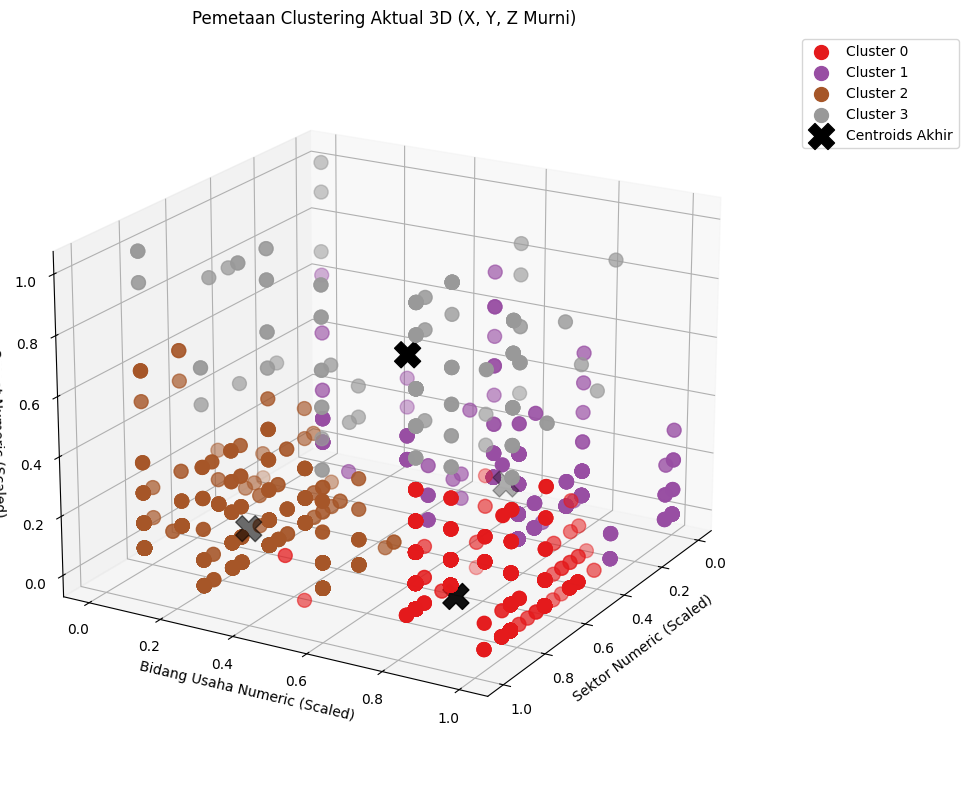


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.5749
   [Interpretasi]: BUKTINYA BAIK. Terdapat struktur klaster yang masuk akal.

2. Davies-Bouldin Index (DBI): 0.7279
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 2187.0200
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 139.4520
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.3026
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [11]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [12]:
import plotly.express as px

# =========================================================
# 1. Visualisasi 3D Interaktif (Sektor vs Bidang vs Omset)
# =========================================================
fig_3d_c7 = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Sektor Numeric
    y=fitur_yang_dipakai[1], # Bidang Usaha Numeric
    z=fitur_yang_dipakai[2], # Omset Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Peta 3D: Pemetaan Sektor, Bidang Usaha, dan Skala Omset",
    opacity=0.8,
    size_max=12,
    color_discrete_sequence=px.colors.qualitative.Dark24
)

fig_3d_c7.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d_c7.show()


# =========================================================
# 2. Bar Chart (Pembandingan Rata-rata Model Bisnis)
# =========================================================
# Mengambil rata-rata metrik dari setiap klaster
df_avg_c7 = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Melakukan transformasi data (melt)
df_melted_c7 = df_avg_c7.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Elemen Bisnis', value_name='Nilai Rata-rata')

# Menggambar diagram batang
fig_bar_c7 = px.bar(
    df_melted_c7, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Elemen Bisnis', 
    barmode='group',
    title="Profil Rata-rata Sektor dan Pendapatan per Klaster"
)
fig_bar_c7.show()
